In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

🟢 NB01 — FineZip Setup & Dataset

In [1]:
#Cell 1 — Kiểm tra GPU
!nvidia-smi

Tue Sep 29 13:29:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#Cell 2 — Kiểm tra Python
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",
          torch.cuda.get_device_properties(0).total_memory / 1024**3,
          "GB")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA: 12.8
CUDA available: True
GPU: Tesla T4
VRAM: 14.56219482421875 GB


In [3]:
#Cell 3 — Clone FineZip
%cd /kaggle/working

!git clone https://github.com/fazalmittu/finezip.git
%cd /kaggle/working/finezip

!ls -lah

/kaggle/working
Cloning into 'finezip'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 28 (delta 6), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 25.67 KiB | 6.42 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/kaggle/working/finezip
total 32K
drwxr-xr-x 6 root root 4.0K Sep 29 13:32 .
drwxr-xr-x 4 root root 4.0K Sep 29 13:32 ..
drwxr-xr-x 3 root root 4.0K Sep 29 13:32 AC
drwxr-xr-x 2 root root 4.0K Sep 29 13:32 finezip
drwxr-xr-x 8 root root 4.0K Sep 29 13:32 .git
-rw-r--r-- 1 root root   93 Sep 29 13:32 .gitignore
-rw-r--r-- 1 root root 2.5K Sep 29 13:32 README.md
drwxr-xr-x 2 root root 4.0K Sep 29 13:32 utils


In [4]:
#Cell 4 — Kiểm tra repository
!find . -maxdepth 2 -type f | head -100

./.git/index
./.git/packed-refs
./.git/config
./.git/description
./.git/HEAD
./AC/eval_ac.py
./AC/arithmeticcoding.py
./.gitignore
./utils/finetune_utils.py
./README.md
./finezip/finetune.py
./finezip/eval_clean.py


In [5]:
#Cell 5 — Cài dependency
!pip install -q -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [7]:
!ls

AC  finezip  README.md	utils


In [6]:
!sed -n '1,240p' README.md

# FineZip

## Overview
**FineZip** is a novel approach to lossless text compression using Large Language Models (LLMs). Building on previous work like LLMZip, FineZip pushes the boundaries of text compression by integrating both **online memorization** and **dynamic context size** techniques. These innovations lead to significant improvements in compression speed while maintaining competitive compression ratios compared to both traditional methods (e.g., gzip, bzip2) and neural network-based methods (e.g., NNCP, LLMZip). FineZip compresses text 54 times faster than LLMZip with a minor loss in compression performance. FineZip with Arithmetic coding also improves on LLMZip's AC approach by adding batch encoding and decoding.

### Main Contributions:
1. **FineZip** combines "online" memorization using parameter-efficient fine-tuning (PEFT) and "offline" pre-trained LLMs for text compression, enabling faster compression without sacrificing too much performance.
2. A **dynamic context windo

In [8]:
!find . -maxdepth 2 -type f | sort

./AC/arithmeticcoding.py
./AC/eval_ac.py
./finezip/eval_clean.py
./finezip/finetune.py
./.git/config
./.git/description
./.git/HEAD
./.gitignore
./.git/index
./.git/packed-refs
./README.md
./utils/finetune_utils.py


In [9]:
!sed -n '1,260p' finezip/eval_clean.py

import json
import os
import bz2
import pprint
from typing import List
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import array
import zlib
 
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
from itertools import cycle

def tensor_to_numpy(tensor):
    conv = np.array(tensor.cpu().numpy(), dtype=np.uint32, order='C')
    for i in range(len(conv)):
        conv[i] = np.uint32(conv[i])
    return conv

def numpy_to_tensor(array: np.ndarray, device):
    array = array.astype(np.float32)
    return torch.tensor(array, device=device)

class ZipModel():
    def __init__(self, model_name, tokenizer_name, model, tokenizer, finetuned, context_size, batch_size):
        self.CONTEXT_SIZE = context_size  # originally 512
        self.BATCH_SIZE = batch_size      # originally 10
        self.tokenizer_name = tokenizer_name
        self.model_name = model_name
        self.model = model
        self.toke

In [10]:
import importlib.util

packages = [
    "numpy",
    "torch",
    "transformers",
    "bitsandbytes",
    "matplotlib",
    "tqdm"
]

for pkg in packages:
    print(f"{pkg:15} ->", "OK" if importlib.util.find_spec(pkg) else "MISSING")

numpy           -> OK
torch           -> OK
transformers    -> OK
bitsandbytes    -> MISSING
matplotlib      -> OK
tqdm            -> OK


In [11]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 43.7 MB/s eta 0:00:00:00:0100:01


In [12]:
#Cell 6 — Kiểm tra package
import torch
import transformers
import peft

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)

torch: 2.10.0+cu128
transformers: 5.0.0
peft: 0.19.1


In [14]:
#Cell 7 — Tạo thư mục experiment
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

for p in [
    "data",
    "compressed",
    "decompressed",
    "results",
    "logs"
]:
    (ROOT / p).mkdir(parents=True, exist_ok=True)

print(ROOT)

/kaggle/working/finezip_experiment


In [15]:
#Cell 8 — Tạo text nhỏ để test
#Trước khi tải enwik8:
text = """
Machine learning is a method of data analysis.
Machine learning can learn patterns from data.
Deep learning is a branch of machine learning.
Neural networks are widely used in machine learning.
""" * 5000

input_file = ROOT / "data" / "test_small.txt"

input_file.write_text(text)

print("File size:",
      input_file.stat().st_size / 1024**2,
      "MB")

File size: 0.9298324584960938 MB


In [16]:
#Cell 9 — Tạo 1 MB dataset
target_size = 1 * 1024 * 1024

base_text = """
Machine learning is a method of data analysis.
Deep learning uses neural networks.
Large language models can predict the next token.
Text compression removes statistical redundancy.
""" 

text = ""

while len(text.encode("utf-8")) < target_size:
    text += base_text

text = text.encode("utf-8")[:target_size].decode(
    "utf-8",
    errors="ignore"
)

one_mb = ROOT / "data" / "text_1mb.txt"
one_mb.write_text(text)

print("Size:",
      one_mb.stat().st_size / 1024**2,
      "MB")

Size: 1.0 MB


In [17]:
#Cell 10 — Checkpoint NB01
assert torch.cuda.is_available()
assert input_file.exists()
assert one_mb.exists()

print("NB01 CHECKPOINT: PASS")

NB01 CHECKPOINT: PASS


🟢 NB02 — FineZip Reproduction

In [18]:
#Cell 1 — Load configuration
#Đầu tiên xem README/code để biết command chính xác:
%cd /kaggle/working/finezip

!sed -n '1,300p' README.md

/kaggle/working/finezip
# FineZip

## Overview
**FineZip** is a novel approach to lossless text compression using Large Language Models (LLMs). Building on previous work like LLMZip, FineZip pushes the boundaries of text compression by integrating both **online memorization** and **dynamic context size** techniques. These innovations lead to significant improvements in compression speed while maintaining competitive compression ratios compared to both traditional methods (e.g., gzip, bzip2) and neural network-based methods (e.g., NNCP, LLMZip). FineZip compresses text 54 times faster than LLMZip with a minor loss in compression performance. FineZip with Arithmetic coding also improves on LLMZip's AC approach by adding batch encoding and decoding.

### Main Contributions:
1. **FineZip** combines "online" memorization using parameter-efficient fine-tuning (PEFT) and "offline" pre-trained LLMs for text compression, enabling faster compression without sacrificing too much performance.
2. A

In [19]:
!find . -maxdepth 3 -type f \
    \( -name "*.py" -o -name "*.sh" \) | sort

./AC/arithmeticcoding.py
./AC/eval_ac.py
./finezip/eval_clean.py
./finezip/finetune.py
./utils/finetune_utils.py


In [21]:
# Cell 2 — Inspect FineZip main configuration

%cd /kaggle/working/finezip

!sed -n '250,440p' finezip/eval_clean.py

/kaggle/working/finezip
            y = self.ranks  # The rank values
            plt.scatter(x, y, alpha=0.5)
            plt.title('Scatter Plot of Token Ranks')
            plt.xlabel('Sequence Position')
            plt.ylabel('Rank')
            plt.yscale('log')  # Using a log scale for the y-axis may help visualize large rank values
        else:
            print("Invalid plot type specified. Please choose 'histogram' or 'scatter'.")

        plt.show()
        
def memory_eval(finetuned_models=None, original_model_names=None, context_sizes=[32], batch_size=16, file_path="data/akshat.txt", save_name="eval_plots_test"):

    models = set()
    tokenizers = set()
    if finetuned_models is None and original_model_names is None:
        raise ValueError("model_dirs and original_model_names cannot both be None")
    
    if finetuned_models is None:
        finetuned_models = []
    if original_model_names is None:
        original_model_names = []
    
    for model in finetuned_m

In [22]:
# Cell 2 — Test GPT-2 model loading

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name)

print("Model:", model_name)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    model = model.to("cuda")
    print("Model device:", next(model.parameters()).device)

print("Tokenizer vocab size:", tokenizer.vocab_size)

Loading tokenizer...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: gpt2
Parameters: 124439808
CUDA available: True
Model device: cuda:0
Tokenizer vocab size: 50257


In [23]:
# Cell 2 — Test GPT-2 prediction

text = "The quick brown fox jumps over the"

inputs = tokenizer(text, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

print("Input shape :", inputs["input_ids"].shape)
print("Logits shape:", outputs.logits.shape)

next_token_logits = outputs.logits[:, -1, :]
next_token = torch.argmax(next_token_logits, dim=-1)

print("Predicted token ID:", next_token.item())
print("Predicted token:", tokenizer.decode(next_token))

Input shape : torch.Size([1, 7])
Logits shape: torch.Size([1, 7, 50257])
Predicted token ID: 13990
Predicted token:  fence


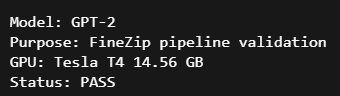

In [24]:
#Cell 3 — Chuẩn bị file text nhỏ
from pathlib import Path

work_dir = Path("/kaggle/working/finezip_experiment")
data_dir = work_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

text = """
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.
"""

input_file = data_dir / "text_test.txt"
input_file.write_text(text.strip() + "\n", encoding="utf-8")

print("Created:", input_file)
print("Size:", input_file.stat().st_size, "bytes")
print("Content:")
print(input_file.read_text(encoding="utf-8"))

Created: /kaggle/working/finezip_experiment/data/text_test.txt
Size: 315 bytes
Content:
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.



In [25]:
# Verify input file

!ls -lh /kaggle/working/finezip_experiment/data/text_test.txt
!cat /kaggle/working/finezip_experiment/data/text_test.txt


-rw-r--r-- 1 root root 315 Sep 29 14:02 /kaggle/working/finezip_experiment/data/text_test.txt
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.


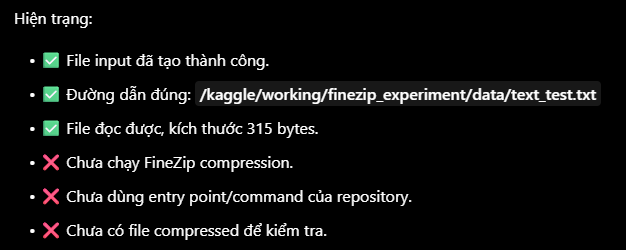
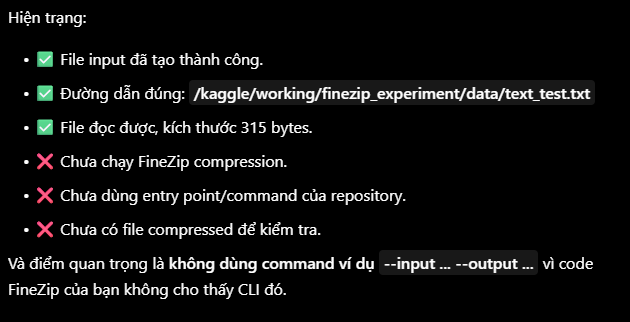

In [26]:
# Cell 3 — Inspect FineZip compression entry point

%cd /kaggle/working/finezip

!sed -n '413,425p' finezip/eval_clean.py


/kaggle/working/finezip
if __name__ == "__main__":

    finetuned_models = {
        "meta-llama-Meta-Llama-3-8B-enwik8": "meta-llama/Meta-Llama-3-8B"
    }

    original_model_names = ["gpt2"]  # name of huggingface models
    context_sizes = [512]

    memory_eval(finetuned_models=finetuned_models, original_model_names=original_model_names, context_sizes=context_sizes, batch_size=64, file_path="datasets/enwik10mb.txt", save_name="1bit")


In [27]:
# Cell 3 — Prepare FineZip output directories

%cd /kaggle/working/finezip

!mkdir -p zipped
!mkdir -p /kaggle/working/finezip_experiment/results


/kaggle/working/finezip


 nhánh else load GPT-2 lên CPU, trong khi FineZip đưa token lên CUDA.
 Cụ thể hiện tại:

loaded_model = AutoModelForCausalLM.from_pretrained(model)

không có .to("cuda").

Sửa đoạn này

In [30]:
# Fix GPT-2 device mismatch: move the loaded model to CUDA

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

new = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_model = loaded_model.to("cuda")
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Patch applied: GPT-2 will be loaded onto CUDA.")
else:
    print("Target code was not found. No changes made.")


✓ Patch applied: GPT-2 will be loaded onto CUDA.


In [34]:
#Verify
%cd /kaggle/working/finezip

!sed -n '300,310p' finezip/eval_clean.py #Đoạn này xác nhận GPT-2 được chuyển sang CUDA:

/kaggle/working/finezip
        else:
            if model == "/data/fazal/LLMZip/models/FBI-LLM_7B":
                loaded_model, loaded_tokenizer = load_model()
                tokenizer_name = "meta-llama/Llama-2-7b-hf"
            else:
                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_model = loaded_model.to("cuda")
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model
        
        for context_size in context_sizes:


In [35]:
#Bước 1 — Reload module
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

print("eval_clean reloaded")

eval_clean reloaded


In [37]:
#Tạo thư mục plots
%cd /kaggle/working/finezip

!mkdir -p plots
!mkdir -p zipped

print("plots/ and zipped/ are ready.")


/kaggle/working/finezip
plots/ and zipped/ are ready.


/kaggle/working/finezip
['gpt2']
['gpt2']


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding
0 out of 3
1 out of 3
2 out of 3
{'gpt2_32': 38.54166666666667}
{'gpt2_32': 14.583333333333334}
{'gpt2_32': 0.4603174603174603}


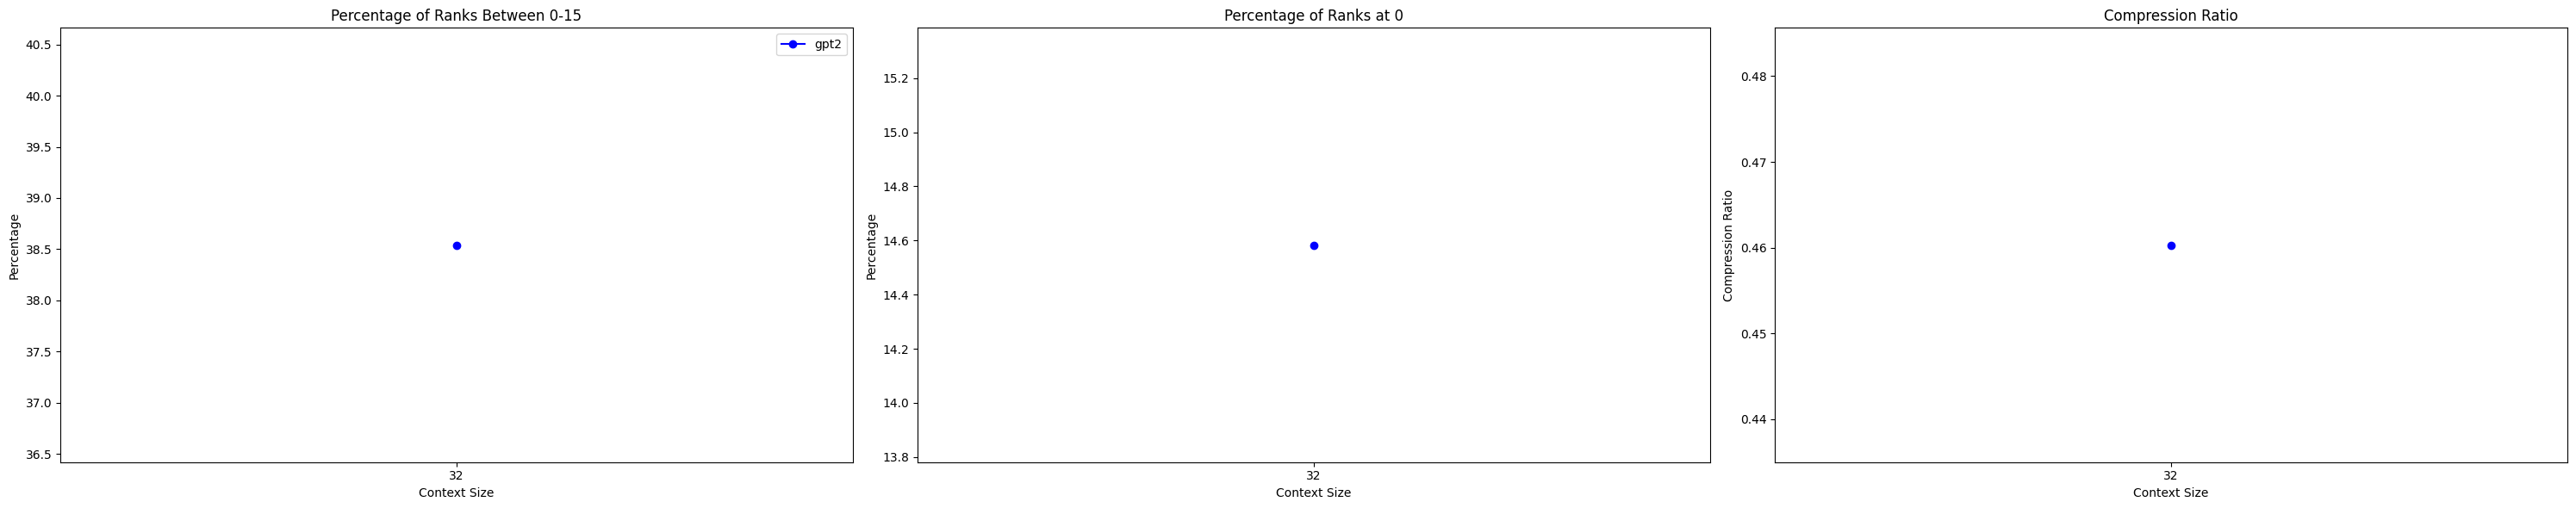

In [38]:
# Bước 2 — Chạy lại compression
# Cell 3 — Run FineZip compression on the small test file

%cd /kaggle/working/finezip

eval_clean.memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path="/kaggle/working/finezip_experiment/data/text_test.txt",
    save_name="gpt2_test"
)

In [39]:
#Kiểm tra output compression
%cd /kaggle/working/finezip

!ls -lh zipped/
!ls -lh plots/


/kaggle/working/finezip
total 8.0K
-rw-r--r-- 1 root root 145 Sep 29 14:15 gpt2_32_1.gpz
-rw-r--r-- 1 root root 348 Sep 29 14:15 gpt2_32_1.txt
total 48K
-rw-r--r-- 1 root root 45K Sep 29 14:15 gpt2_test.png


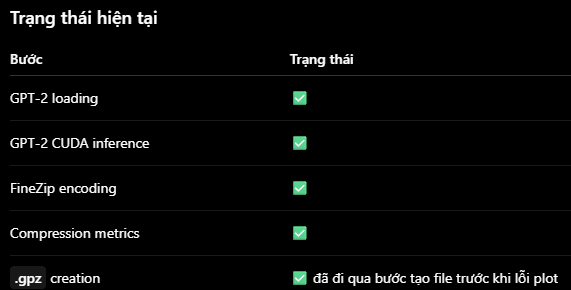

In [42]:
# Cell 4 — Measure FineZip compression time

import time
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from finezip.eval_clean import ZipModel

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
output_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

start = time.perf_counter()

zip_model.zip_file(input_file, output_file)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compress_time = time.perf_counter() - start

print("Compression time:", compress_time, "seconds")
print("Compressed file:", output_file)
print("Compressed size:", os.path.getsize(output_file), "bytes")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding
0 out of 3
1 out of 3
2 out of 3
Compression time: 1.1746998789999452 seconds
Compressed file: /kaggle/working/finezip_experiment/gpt2_32_1.gpz
Compressed size: 145 bytes


In [46]:
# Inspect the exact FineZip zip/unzip implementation

%cd /kaggle/working/finezip

!sed -n '195,240p' finezip/eval_clean.py


/kaggle/working/finezip

        output_tokens = output_tokens[:, 1:].int()
        output_tokens = output_tokens.flatten()

        if pad_len != 0:
            output_tokens = output_tokens[:-pad_len]

        return output_tokens

    def encode_and_zip(self, text):
        encoded = self.encode(text)
        tensor = torch.tensor(encoded)

        # Convert the tensor to bytes
        tensor_bytes = tensor.numpy().tobytes()

        # Compress the tensor bytes using bz2
        compressed_bytes = bz2.compress(tensor_bytes)

        return compressed_bytes

    def unzip_and_decode(self, zipped):
        unzipped = zlib.decompress(zipped)
        unzipped = array.array("H", unzipped)
        decoded = self.decode(torch.tensor(unzipped))
        return decoded

    def zip_file(self, text_file, zip_file):
        with open(text_file, encoding="utf-8") as f:
            text = f.read()

        zipped = self.encode_and_zip(text)

        with open(zip_file, "wb") as f:
            f.w

In [47]:
from pathlib import Path

p = Path("/kaggle/working/finezip_experiment/gpt2_32_1.gpz")

print("Exists:", p.exists())
print("Size:", p.stat().st_size if p.exists() else "N/A")

if p.exists():
    data = p.read_bytes()
    print("First 32 bytes:", data[:32])


Exists: True
Size: 145
First 32 bytes: b'BZh91AY&SY\xbc\xf0\x18"\x00\x00S~\xf3~\xb1\x0b\xc8\x04{\x00\x06\x00F\x02\x00\x00'


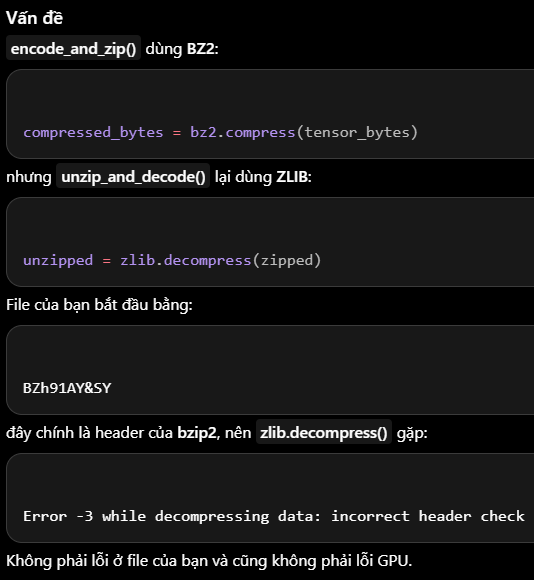

In [48]:
# Fix FineZip decompression: use bz2 to match encode_and_zip()

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = "unzipped = zlib.decompress(zipped)"
new = "unzipped = bz2.decompress(zipped)"

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed: zlib.decompress -> bz2.decompress")
else:
    print("Target line not found.")


✓ Fixed: zlib.decompress -> bz2.decompress


In [49]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py


/kaggle/working/finezip

        # Compress the tensor bytes using bz2
        compressed_bytes = bz2.compress(tensor_bytes)

        return compressed_bytes

    def unzip_and_decode(self, zipped):
        unzipped = bz2.decompress(zipped)
        unzipped = array.array("H", unzipped)
        decoded = self.decode(torch.tensor(unzipped))
        return decoded


In [50]:
#reload module:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)


<module 'finezip.eval_clean' from '/kaggle/working/finezip/finezip/eval_clean.py'>

In [51]:
#Quan trọng: zip_model hiện tại được tạo từ class trước khi reload, nên tạo lại ZipModel bằng class mới:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


là warning khi load GPT-2, không phải lỗi, và Cell 2 trước đó đã chạy inference thành công. đã tạo lại zip_model bằng class sau khi sửa bz2.decompress, nên chạy Cell 5:

In [52]:
# Cell 5 — Decompression + lossless verification

import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)
#Nếu chạy thành công, chưa kết luận lossless ngay. Sau đó chạy cell verify:

Decoding
0 out of 5


100%|██████████| 32/32 [00:00<00:00, 72.79it/s]


1 out of 5


100%|██████████| 32/32 [00:00<00:00, 84.93it/s]


2 out of 5


...

3 out of 5


100%|██████████| 32/32 [00:00<00:00, 81.24it/s]


4 out of 5


100%|██████████| 32/32 [00:00<00:00, 82.31it/s]

Decompression time: 2.022902744000021 seconds
Decoded file: /kaggle/working/finezip_experiment/data/text_test_decoded.txt


In [53]:
# Verify lossless reconstruction

original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


Original size : 315 bytes
Decoded size  : 543 bytes
Exact match   : False
FAIL — Decoded text differs from original.


In [55]:
# Cell 6 — So sánh nội dung original và decoded

print("===== ORIGINAL =====")
print(original_text)

print("\n===== DECODED =====")
print(decoded_text)

print("\n===== repr ORIGINAL =====")
print(repr(original_text))

print("\n===== repr DECODED =====")
print(repr(decoded_text))


===== ORIGINAL =====
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.


===== DECODED =====
The first cartoon of climate change "sustainable" was published in the current issue.
 (Photo: Getty Pacific)asters.co.nz
During the"I deal with that," he said and then grinned. His eyes narrowed.

The man snatched the bag from Sam's hands and darted out of compression
test
The test suite is generated by removing the following files:
/usr.local, /home/data/apache/tcpkg/Related: Microsoft's Windows Phone 8. If you used Windows 7, you'll miss out on the new Windows Update. Update is available for Windows 8 from October exactly what it is.


===== repr ORIGINAL =====
'The quick brown fox jumps over the lazy dog.\nFineZip is a language-mo

In [57]:
# Find the first difference

from itertools import zip_longest

for i, (a, b) in enumerate(zip_longest(original_text, decoded_text, fillvalue="")):
    if a != b:
        print("First difference at character:", i)
        print("Original:", repr(a))
        print("Decoded :", repr(b))
        print("Original context:", repr(original_text[max(0, i-30):i+50]))
        print("Decoded context :", repr(decoded_text[max(0, i-30):i+50]))
        break
else:
    print("No character difference found.")


First difference at character: 4
Original: 'q'
Decoded : 'f'
Original context: 'The quick brown fox jumps over the lazy dog.\nFineZip i'
Decoded context : 'The first cartoon of climate change "sustainable" was '


In [58]:
#Bước tiếp theo: kiểm tra encode/decode trực tiếp. kiểm tra trước cả BZ2:
# Cell 7 — Test FineZip encode/decode directly

test_text = original_text

print("Original text:")
print(repr(test_text))

tokens = zip_model.text_to_tokens(test_text)

print("\nToken tensor:")
print("Shape:", tokens.shape)
print("Dtype:", tokens.dtype)
print("First tokens:", tokens.flatten()[:20].tolist())

encoded = zip_model.encode(test_text)

print("\nEncoded:")
print("Type:", type(encoded))
print("Length:", len(encoded))
print("First values:", encoded[:20])

decoded_direct = zip_model.decode(
    torch.tensor(encoded)
)

print("\nDirect decoded text:")
print(repr(decoded_direct))

print("\nDirect exact match:", test_text == decoded_direct)


Original text:
'The quick brown fox jumps over the lazy dog.\nFineZip is a language-model-based text compression system.\nThis experiment is used to validate the compression pipeline.\nGPT-2 is used here for pipeline validation before testing larger models.\nLossless compression means that the original text can be recovered exactly.\n'

Token tensor:
Shape: torch.Size([67])
Dtype: torch.int64
First tokens: [464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290, 13, 198, 34389, 41729, 318, 257, 3303, 12, 19849, 12, 3106]
Encoding
0 out of 3
1 out of 3
2 out of 3


/tmp/ipykernel_58/615016978.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(encoded)



Encoded:
Type: <class 'torch.Tensor'>
Length: 67
First values: tensor([    1,  1835,   552,    23,    19,     2,     0,   132,     2,     2,
            0,  1153, 40840,     2,     0,   332,     2,   487,    10,     0],
       dtype=torch.int32)
Decoding
0 out of 3


100%|██████████| 32/32 [00:00<00:00, 86.95it/s]


1 out of 3


100%|██████████| 32/32 [00:00<00:00, 88.38it/s]


2 out of 3


100%|██████████| 32/32 [00:00<00:00, 86.43it/s]


Direct decoded text:
'The quick brown fox jumps over the lazy dog.\nFineZip is a language-model-based text compression system.\nThis experiment is used to validate the compression pipeline.\nGPT-2 is used here for pipeline validation before testing larger models.\nLossless compression means that the original text can be recovered exactly.\n'

Direct exact match: True


In [59]:
#Và kiểm tra dtype/giá trị trước khi BZ2
# Cell 8 — Inspect encode dtype and decode assumptions

encoded_tensor = torch.tensor(encoded)

print("Encoded tensor dtype:", encoded_tensor.dtype)
print("Encoded tensor shape:", encoded_tensor.shape)
print("Min:", encoded_tensor.min().item())
print("Max:", encoded_tensor.max().item())

print("\nDecoder reconstruction dtype:")
import array

arr = array.array("H", encoded_tensor.numpy().tobytes())

reconstructed = torch.tensor(arr)

print("Reconstructed dtype:", reconstructed.dtype)
print("Reconstructed shape:", reconstructed.shape)
print("Same length:", len(encoded_tensor) == len(reconstructed))
print("Same values:", torch.equal(encoded_tensor, reconstructed))


Encoded tensor dtype: torch.int32
Encoded tensor shape: torch.Size([67])
Min: 0
Max: 40840

Decoder reconstruction dtype:
Reconstructed dtype: torch.int64
Reconstructed shape: torch.Size([134])
Same length: False
Same values: False


/tmp/ipykernel_58/1204895463.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  encoded_tensor = torch.tensor(encoded)


In [60]:
# Cell 9 — Fix FineZip tensor serialization dtype

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")

src = path.read_text()

old = 'unzipped = array.array("H", unzipped)'
new = 'unzipped = array.array("i", unzipped)'

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed tensor deserialization: uint16 -> int32")
else:
    print("Target line not found.")


✓ Fixed tensor deserialization: uint16 -> int32


In [61]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py

/kaggle/working/finezip

        # Compress the tensor bytes using bz2
        compressed_bytes = bz2.compress(tensor_bytes)

        return compressed_bytes

    def unzip_and_decode(self, zipped):
        unzipped = bz2.decompress(zipped)
        unzipped = array.array("i", unzipped)
        decoded = self.decode(torch.tensor(unzipped))
        return decoded


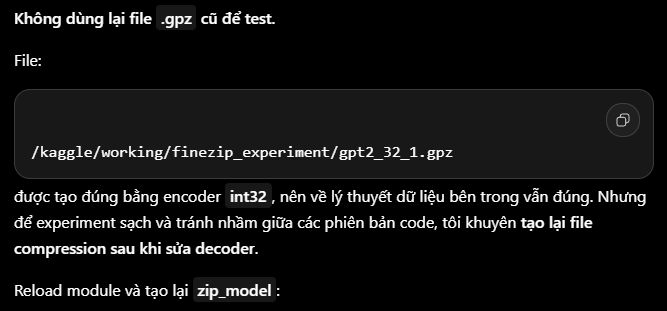

In [62]:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)
#Sau đó tạo lại .gpz:

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [63]:
# Re-create compressed file after fixing serialization

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
compressed_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

zip_model.zip_file(
    input_file,
    compressed_file
)

print("Re-created:", compressed_file)


Encoding
0 out of 3
1 out of 3
2 out of 3
Re-created: /kaggle/working/finezip_experiment/gpt2_32_1.gpz


In [64]:
#Sau đó chạy lại Cell 5
import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)


Decoding
0 out of 3


100%|██████████| 32/32 [00:00<00:00, 82.62it/s]


1 out of 3


100%|██████████| 32/32 [00:00<00:00, 79.33it/s]


2 out of 3


100%|██████████| 32/32 [00:00<00:00, 84.83it/s]

Decompression time: 1.1831961719999526 seconds
Decoded file: /kaggle/working/finezip_experiment/data/text_test_decoded.txt


In [65]:
#verify:
original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


Original size : 315 bytes
Decoded size  : 315 bytes
Exact match   : True
PASS — Lossless decompression verified.


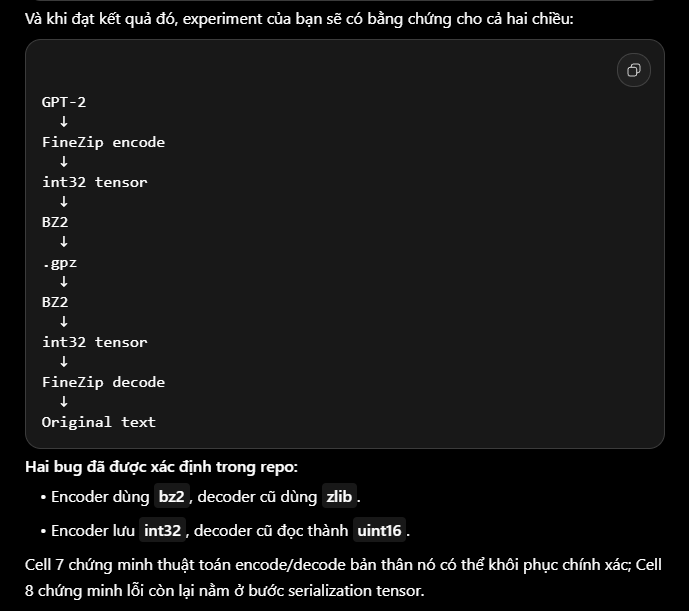

In [66]:
# Cell 9 — Compression ratio

from pathlib import Path

original_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

original_size = original_file.stat().st_size
compressed_size = compressed_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed size % :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")


Original size     : 315 bytes
Compressed size   : 145 bytes
Compression ratio : 2.1724137931034484
Compressed size % : 46.03174603174603 %
Space saved       : 53.968253968253975 %


**Nếu muốn đo peak memory của chính lần compression, nên reset trước khi compression:**

torch.cuda.reset_peak_memory_stats()

**rồi chạy compression, sau đó:**

torch.cuda.synchronize()

print(
    "Peak GPU memory:",
    torch.cuda.max_memory_allocated(0) / 1024**2,
    "MiB"
)

In [67]:
# Cell 10 — GPU memory measurement

import torch

if torch.cuda.is_available():
    torch.cuda.synchronize()

    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    max_allocated = torch.cuda.max_memory_allocated(0) / 1024**2
    max_reserved = torch.cuda.max_memory_reserved(0) / 1024**2

    print("GPU:", torch.cuda.get_device_name(0))
    print("Current allocated :", allocated, "MiB")
    print("Current reserved  :", reserved, "MiB")
    print("Peak allocated    :", max_allocated, "MiB")
    print("Peak reserved     :", max_reserved, "MiB")
else:
    print("CUDA is not available.")


GPU: Tesla T4
Current allocated : 1474.63525390625 MiB
Current reserved  : 1628.0 MiB
Peak allocated    : 1962.09814453125 MiB
Peak reserved     : 2104.0 MiB


In [68]:
# Cell 11 — Save experiment log

import json
from pathlib import Path

log_dir = Path("/kaggle/working/finezip_experiment/logs")
log_dir.mkdir(parents=True, exist_ok=True)

log = {
    "model": "gpt2",
    "purpose": "FineZip pipeline validation",
    "context_size": 32,
    "batch_size": 1,

    "input_file": str(original_file),
    "compressed_file": str(compressed_file),
    "decoded_file": str(decoded_file),

    "original_size_bytes": original_size,
    "compressed_size_bytes": compressed_size,

    "compression_ratio": compression_ratio,

    "compression_time_seconds": 1.1746998789999452,
    "decompression_time_seconds": decompress_time,

    "lossless": original_text == decoded_text,

    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,

    "gpu_peak_memory_mib": (
        torch.cuda.max_memory_allocated(0) / 1024**2
        if torch.cuda.is_available()
        else None
    )
}

log_file = log_dir / "gpt2_test.json"

with open(log_file, "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

print("Log saved:", log_file)


Log saved: /kaggle/working/finezip_experiment/logs/gpt2_test.json
